<a href="https://colab.research.google.com/github/pratyushadk/ML-Lab/blob/main/Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML Lab 02

In [4]:
!pip install openpyxl seaborn matplotlib scikit-learn -q

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

## A1 — Purchase Data: Rank & Pseudo-Inverse

In [6]:
def load_purchase_data(filepath):
    df = pd.read_excel(filepath, sheet_name='Purchase data')
    df = df[['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)', 'Payment (Rs)']].dropna()
    X = df[['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)']].values.astype(float)
    y = df['Payment (Rs)'].values.astype(float).reshape(-1, 1)
    return X, y

def compute_rank(matrix):
    return np.linalg.matrix_rank(matrix)

def compute_pseudo_inverse_solution(X, y):
    X_pinv = np.linalg.pinv(X)
    cost_vector = X_pinv @ y
    return cost_vector

def main_a1():
    X, y = load_purchase_data('Lab Session Data.xlsx')
    print("=== A1: Purchase Data Analysis ===")
    print(f"Shape of X (feature matrix): {X.shape}")
    print(f"Shape of y (output vector) : {y.shape}")
    print(f"Dimensionality of vector space: {X.shape[1]}")
    print(f"Number of vectors (observations): {X.shape[0]}")
    rank = compute_rank(X)
    print(f"Rank of feature matrix X: {rank}")
    costs = compute_pseudo_inverse_solution(X, y)
    labels = ['Candy (Rs/unit)', 'Mango (Rs/Kg)', 'Milk Packet (Rs/unit)']
    print("\nEstimated cost per product (via pseudo-inverse):")
    for label, val in zip(labels, costs.flatten()):
        print(f"  {label}: Rs {val:.4f}")

main_a1()

=== A1: Purchase Data Analysis ===
Shape of X (feature matrix): (10, 3)
Shape of y (output vector) : (10, 1)
Dimensionality of vector space: 3
Number of vectors (observations): 10
Rank of feature matrix X: 3

Estimated cost per product (via pseudo-inverse):
  Candy (Rs/unit): Rs 1.0000
  Mango (Rs/Kg): Rs 55.0000
  Milk Packet (Rs/unit): Rs 18.0000


## A2 — RICH / POOR Classifier

In [7]:
def label_customers(y_flat, threshold=200):
    return np.where(y_flat > threshold, 'RICH', 'POOR')

def train_classifier(X, labels):
    le = LabelEncoder()
    y_enc = le.fit_transform(labels)
    clf = KNeighborsClassifier(n_neighbors=3)
    clf.fit(X, y_enc)
    return clf, le

def classify_all(clf, le, X):
    return le.inverse_transform(clf.predict(X))

def main_a2():
    X, y = load_purchase_data('Lab Session Data.xlsx')
    labels = label_customers(y.flatten())
    print("=== A2: RICH / POOR Customer Classification ===")
    print("Customer labels:")
    for i, (pay, lbl) in enumerate(zip(y.flatten(), labels), 1):
        print(f"  C_{i}: Rs {pay:.0f} -> {lbl}")
    clf, le = train_classifier(X, labels)
    preds = classify_all(clf, le, X)
    acc = accuracy_score(labels, preds)
    print(f"\nKNN Training Accuracy: {acc * 100:.1f}%")
    print("Predicted:", preds)
    print("Actual   :", labels)

main_a2()

=== A2: RICH / POOR Customer Classification ===
Customer labels:
  C_1: Rs 386 -> RICH
  C_2: Rs 289 -> RICH
  C_3: Rs 393 -> RICH
  C_4: Rs 110 -> POOR
  C_5: Rs 280 -> RICH
  C_6: Rs 167 -> POOR
  C_7: Rs 271 -> RICH
  C_8: Rs 274 -> RICH
  C_9: Rs 148 -> POOR
  C_10: Rs 198 -> POOR

KNN Training Accuracy: 90.0%
Predicted: ['RICH' 'RICH' 'RICH' 'POOR' 'RICH' 'POOR' 'RICH' 'RICH' 'POOR' 'RICH']
Actual   : ['RICH' 'RICH' 'RICH' 'POOR' 'RICH' 'POOR' 'RICH' 'RICH' 'POOR' 'POOR']


## A3 — IRCTC Stock Price Analysis

=== A3: IRCTC Stock Price Analysis ===
Population Mean  - numpy : 1560.6635 | custom : 1560.6635
Population Var   - numpy : 58496.4924 | custom : 58496.4924

Avg time (10 runs) - Mean : numpy=7.99us | custom=14.28us
Avg time (10 runs) - Var  : numpy=23.39us | custom=79.75us

Wednesday sample mean : 1550.7060
Population mean       : 1560.6635
Difference            : 9.9575
Observation: Wednesday mean differs slightly from population mean; mid-week trading activity varies.

April sample mean : 1698.9526
Population mean   : 1560.6635
Difference        : 138.2892
Observation: April prices reflect seasonal trends; sample mean may not represent the full year.

P(loss)                  : 0.4980 (49.80%)
P(profit on Wednesday)   : 0.4200 (42.00%)
P(profit | Wednesday)    : 0.4200 (42.00%)


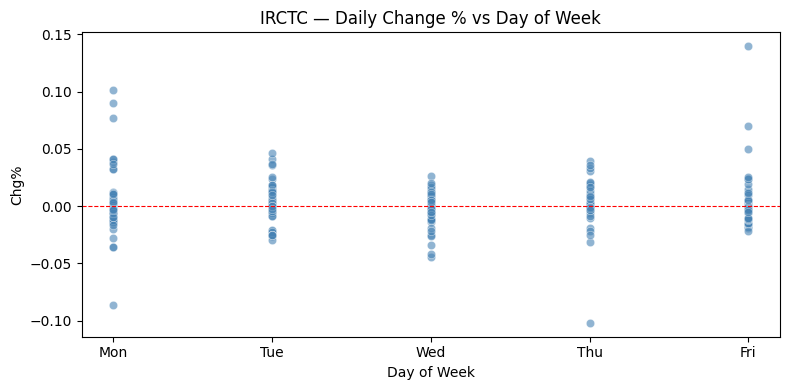

In [8]:
def load_irctc_data(filepath):
    df = pd.read_excel(filepath, sheet_name='IRCTC Stock Price')
    df.columns = df.columns.str.strip()
    df = df.dropna(subset=['Price'])
    df['Chg%'] = pd.to_numeric(df['Chg%'], errors='coerce')
    return df

def numpy_mean(arr):
    return np.mean(arr)

def numpy_var(arr):
    return np.var(arr)

def custom_mean(arr):
    return sum(arr) / len(arr)

def custom_var(arr):
    mu = custom_mean(arr)
    return sum((x - mu) ** 2 for x in arr) / len(arr)

def benchmark_function(func, arr, runs=10):
    times = []
    for _ in range(runs):
        start = time.perf_counter()
        func(arr)
        times.append(time.perf_counter() - start)
    return sum(times) / runs

def wednesday_mean(df):
    wed = df[df['Day'] == 'Wed']['Price'].values
    return np.mean(wed), wed

def april_mean(df):
    apr = df[df['Month'] == 'Apr']['Price'].values
    return np.mean(apr), apr

def loss_probability(chg):
    valid = chg[~np.isnan(chg)]
    negatives = list(filter(lambda x: x < 0, valid))
    return len(negatives) / len(valid)

def profit_on_wednesday(df):
    wed_chg = df[df['Day'] == 'Wed']['Chg%'].dropna().values
    return np.sum(wed_chg > 0) / len(wed_chg) if len(wed_chg) > 0 else 0

def conditional_profit_given_wednesday(df):
    total = len(df['Day'])
    wed_df = df[df['Day'] == 'Wed']
    p_wed = len(wed_df) / total
    p_profit_and_wed = np.sum(wed_df['Chg%'].dropna() > 0) / total
    return p_profit_and_wed / p_wed if p_wed > 0 else 0

def scatter_chg_vs_day(df):
    day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
    day_map = {d: i for i, d in enumerate(day_order)}
    df_clean = df.dropna(subset=['Chg%', 'Day'])
    x = df_clean['Day'].map(day_map)
    y = df_clean['Chg%']
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(x, y, alpha=0.6, color='steelblue', edgecolors='white', linewidths=0.4)
    ax.set_xticks(range(len(day_order)))
    ax.set_xticklabels(day_order)
    ax.set_xlabel('Day of Week')
    ax.set_ylabel('Chg%')
    ax.set_title('IRCTC — Daily Change % vs Day of Week')
    ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
    plt.tight_layout()
    plt.show()

def main_a3():
    df = load_irctc_data('Lab Session Data.xlsx')
    prices = df['Price'].values
    chg = df['Chg%'].values

    print("=== A3: IRCTC Stock Price Analysis ===")
    np_m = numpy_mean(prices)
    np_v = numpy_var(prices)
    cu_m = custom_mean(prices)
    cu_v = custom_var(list(prices))

    print(f"Population Mean  - numpy : {np_m:.4f} | custom : {cu_m:.4f}")
    print(f"Population Var   - numpy : {np_v:.4f} | custom : {cu_v:.4f}")

    t_np_m = benchmark_function(numpy_mean, prices)
    t_cu_m = benchmark_function(custom_mean, list(prices))
    t_np_v = benchmark_function(numpy_var, prices)
    t_cu_v = benchmark_function(custom_var, list(prices))
    print(f"\nAvg time (10 runs) - Mean : numpy={t_np_m*1e6:.2f}us | custom={t_cu_m*1e6:.2f}us")
    print(f"Avg time (10 runs) - Var  : numpy={t_np_v*1e6:.2f}us | custom={t_cu_v*1e6:.2f}us")

    wed_m, _ = wednesday_mean(df)
    print(f"\nWednesday sample mean : {wed_m:.4f}")
    print(f"Population mean       : {np_m:.4f}")
    print(f"Difference            : {abs(wed_m - np_m):.4f}")
    print("Observation: Wednesday mean differs slightly from population mean; mid-week trading activity varies.")

    apr_m, _ = april_mean(df)
    print(f"\nApril sample mean : {apr_m:.4f}")
    print(f"Population mean   : {np_m:.4f}")
    print(f"Difference        : {abs(apr_m - np_m):.4f}")
    print("Observation: April prices reflect seasonal trends; sample mean may not represent the full year.")

    p_loss = loss_probability(chg)
    print(f"\nP(loss)                  : {p_loss:.4f} ({p_loss*100:.2f}%)")
    p_pw = profit_on_wednesday(df)
    print(f"P(profit on Wednesday)   : {p_pw:.4f} ({p_pw*100:.2f}%)")
    p_cond = conditional_profit_given_wednesday(df)
    print(f"P(profit | Wednesday)    : {p_cond:.4f} ({p_cond*100:.2f}%)")

    scatter_chg_vs_day(df)

main_a3()

## A4 — Thyroid Data Exploration

In [9]:
def load_thyroid_data(filepath):
    df = pd.read_excel(filepath, sheet_name='thyroid0387_UCI')
    df.replace('?', np.nan, inplace=True)
    return df

def identify_dtypes(df):
    binary_cols = [c for c in df.columns if df[c].dropna().isin(['t', 'f']).all()]
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in df.columns if c not in numeric_cols and c not in binary_cols]
    return binary_cols, numeric_cols, categorical_cols

def missing_value_report(df):
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    report = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
    return report[report['Missing Count'] > 0]

def outlier_summary(df, numeric_cols):
    result = {}
    for col in numeric_cols:
        vals = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(vals) == 0:
            continue
        q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
        iqr = q3 - q1
        cnt = ((vals < q1 - 1.5 * iqr) | (vals > q3 + 1.5 * iqr)).sum()
        result[col] = int(cnt)
    return result

def numeric_stats(df, numeric_cols):
    stats = {}
    for col in numeric_cols:
        vals = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(vals) > 0:
            stats[col] = {'mean': np.mean(vals), 'std': np.std(vals), 'var': np.var(vals)}
    return stats

def main_a4():
    df = load_thyroid_data('Lab Session Data.xlsx')
    binary_cols, numeric_cols, categorical_cols = identify_dtypes(df)

    print("=== A4: Thyroid Data Exploration ===")
    print(f"Dataset shape: {df.shape}")

    print("\n--- Attribute Datatypes ---")
    print(f"Binary (t/f) cols  ({len(binary_cols)}): {binary_cols}")
    print(f"Numeric cols       ({len(numeric_cols)}): {numeric_cols}")
    print(f"Categorical cols   ({len(categorical_cols)}): {categorical_cols}")

    print("\n--- Encoding Strategy ---")
    print("Binary (t/f) cols         -> Label Encoding (0/1)")
    print("'sex' column              -> Label Encoding (M=1, F=0)")
    print("'referral source' column  -> One-Hot Encoding (nominal)")
    print("'Condition' column        -> Label Encoding (target variable)")

    print("\n--- Numeric Column Ranges ---")
    for col in numeric_cols:
        vals = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(vals) > 0:
            print(f"  {col:10s}: min={vals.min():.2f}, max={vals.max():.2f}")

    missing = missing_value_report(df)
    print("\n--- Missing Values ---")
    print(missing.to_string())

    outliers = outlier_summary(df, numeric_cols)
    print("\n--- Outlier Counts (IQR Method) ---")
    for col, cnt in outliers.items():
        print(f"  {col:10s}: {cnt} outliers")

    stats = numeric_stats(df, numeric_cols)
    print("\n--- Mean & Variance ---")
    for col, s in stats.items():
        print(f"  {col:10s}: mean={s['mean']:.4f}, std={s['std']:.4f}, var={s['var']:.4f}")

main_a4()

=== A4: Thyroid Data Exploration ===
Dataset shape: (9172, 31)

--- Attribute Datatypes ---
Binary (t/f) cols  (20): ['on thyroxine', 'query on thyroxine', 'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery', 'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'T3 measured', 'TT4 measured', 'T4U measured', 'FTI measured', 'TBG measured']
Numeric cols       (8): ['Record ID', 'age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI', 'TBG']
Categorical cols   (3): ['sex', 'referral source', 'Condition']

--- Encoding Strategy ---
Binary (t/f) cols         -> Label Encoding (0/1)
'sex' column              -> Label Encoding (M=1, F=0)
'referral source' column  -> One-Hot Encoding (nominal)
'Condition' column        -> Label Encoding (target variable)

--- Numeric Column Ranges ---
  Record ID : min=840801013.00, max=870119035.00
  age       : min=1.00, max=65526.00
  TSH       : min=0.01, max=530.00
  T3        

## A5 — Jaccard Coefficient & SMC

In [10]:
def extract_binary_vectors(df, binary_cols, row_indices):
    sub = df[binary_cols].iloc[row_indices].copy()
    for col in binary_cols:
        sub[col] = sub[col].map({'t': 1, 'f': 0})
    return sub.values.astype(float)

def jaccard_coefficient(v1, v2):
    f11 = np.sum((v1 == 1) & (v2 == 1))
    f10 = np.sum((v1 == 1) & (v2 == 0))
    f01 = np.sum((v1 == 0) & (v2 == 1))
    denom = f11 + f10 + f01
    return float(f11 / denom) if denom > 0 else 0.0

def simple_matching_coefficient(v1, v2):
    f11 = np.sum((v1 == 1) & (v2 == 1))
    f00 = np.sum((v1 == 0) & (v2 == 0))
    f10 = np.sum((v1 == 1) & (v2 == 0))
    f01 = np.sum((v1 == 0) & (v2 == 1))
    total = f11 + f00 + f10 + f01
    return float((f11 + f00) / total) if total > 0 else 0.0

def main_a5():
    df = load_thyroid_data('Lab Session Data.xlsx')
    binary_cols, _, _ = identify_dtypes(df)
    vecs = extract_binary_vectors(df, binary_cols, [0, 1])
    v1, v2 = vecs[0], vecs[1]

    jc = jaccard_coefficient(v1, v2)
    smc = simple_matching_coefficient(v1, v2)

    print("=== A5: Jaccard Coefficient & SMC ===")
    print(f"Binary vector (obs 1): {v1}")
    print(f"Binary vector (obs 2): {v2}")
    print(f"Jaccard Coefficient (JC) : {jc:.4f}")
    print(f"Simple Matching Coeff    : {smc:.4f}")
    print("\nInterpretation:")
    print("  SMC includes 0-0 matches; better for symmetric binary data.")
    print("  JC ignores 0-0 co-absences; preferred for asymmetric data")
    print("  (where both being absent is not informative).")
    print(f"  JC={jc:.4f} <= SMC={smc:.4f} since SMC rewards double-zero agreements.")

main_a5()

=== A5: Jaccard Coefficient & SMC ===
Binary vector (obs 1): [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
Binary vector (obs 2): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0.]
Jaccard Coefficient (JC) : 0.2500
Simple Matching Coeff    : 0.8500

Interpretation:
  SMC includes 0-0 matches; better for symmetric binary data.
  JC ignores 0-0 co-absences; preferred for asymmetric data
  (where both being absent is not informative).
  JC=0.2500 <= SMC=0.8500 since SMC rewards double-zero agreements.


## A6 — Cosine Similarity (Full Vectors)

In [11]:
def prepare_full_vector(df, row_idx):
    row = df.iloc[row_idx].copy()
    encoded = []
    for val in row.values:
        if val == 't':
            encoded.append(1.0)
        elif val == 'f':
            encoded.append(0.0)
        elif val == 'M':
            encoded.append(1.0)
        elif val == 'F':
            encoded.append(0.0)
        else:
            try:
                encoded.append(float(val))
            except (ValueError, TypeError):
                encoded.append(0.0)
    return np.array(encoded, dtype=float)

def cosine_similarity(v1, v2):
    dot = np.dot(v1, v2)
    n1 = np.linalg.norm(v1)
    n2 = np.linalg.norm(v2)
    if n1 == 0 or n2 == 0:
        return 0.0
    return float(dot / (n1 * n2))

def main_a6():
    df = load_thyroid_data('Lab Session Data.xlsx')
    v1 = prepare_full_vector(df, 0)
    v2 = prepare_full_vector(df, 1)
    cos = cosine_similarity(v1, v2)

    print("=== A6: Cosine Similarity ===")
    print(f"Full encoded vector (obs 1): {v1}")
    print(f"Full encoded vector (obs 2): {v2}")
    print(f"Cosine Similarity: {cos:.4f}")
    print("\nInterpretation:")
    print("  Value close to 1 -> vectors point in nearly the same direction (very similar).")
    print("  Cosine similarity is magnitude-independent; captures orientation in feature space.")

main_a6()

=== A6: Cosine Similarity ===
Full encoded vector (obs 1): [8.40801013e+08 2.90000000e+01 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 1.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.00000000e+00 3.00000000e-01 0.00000000e+00
            nan 0.00000000e+00            nan 0.00000000e+00
            nan 0.00000000e+00            nan 0.00000000e+00
            nan 0.00000000e+00 0.00000000e+00]
Full encoded vector (obs 2): [8.40801014e+08 2.90000000e+01 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.00000000e+00 1.60000000e+00 1.00000000e+00
 1.90000000e+00 1.00000000e+00 1.28000000e+02 0.00000000e+00
            nan 0.00000000e+00            nan 0.00000000e+00
           

## A7 — Heatmap of JC, SMC, Cosine (First 20 Observations)

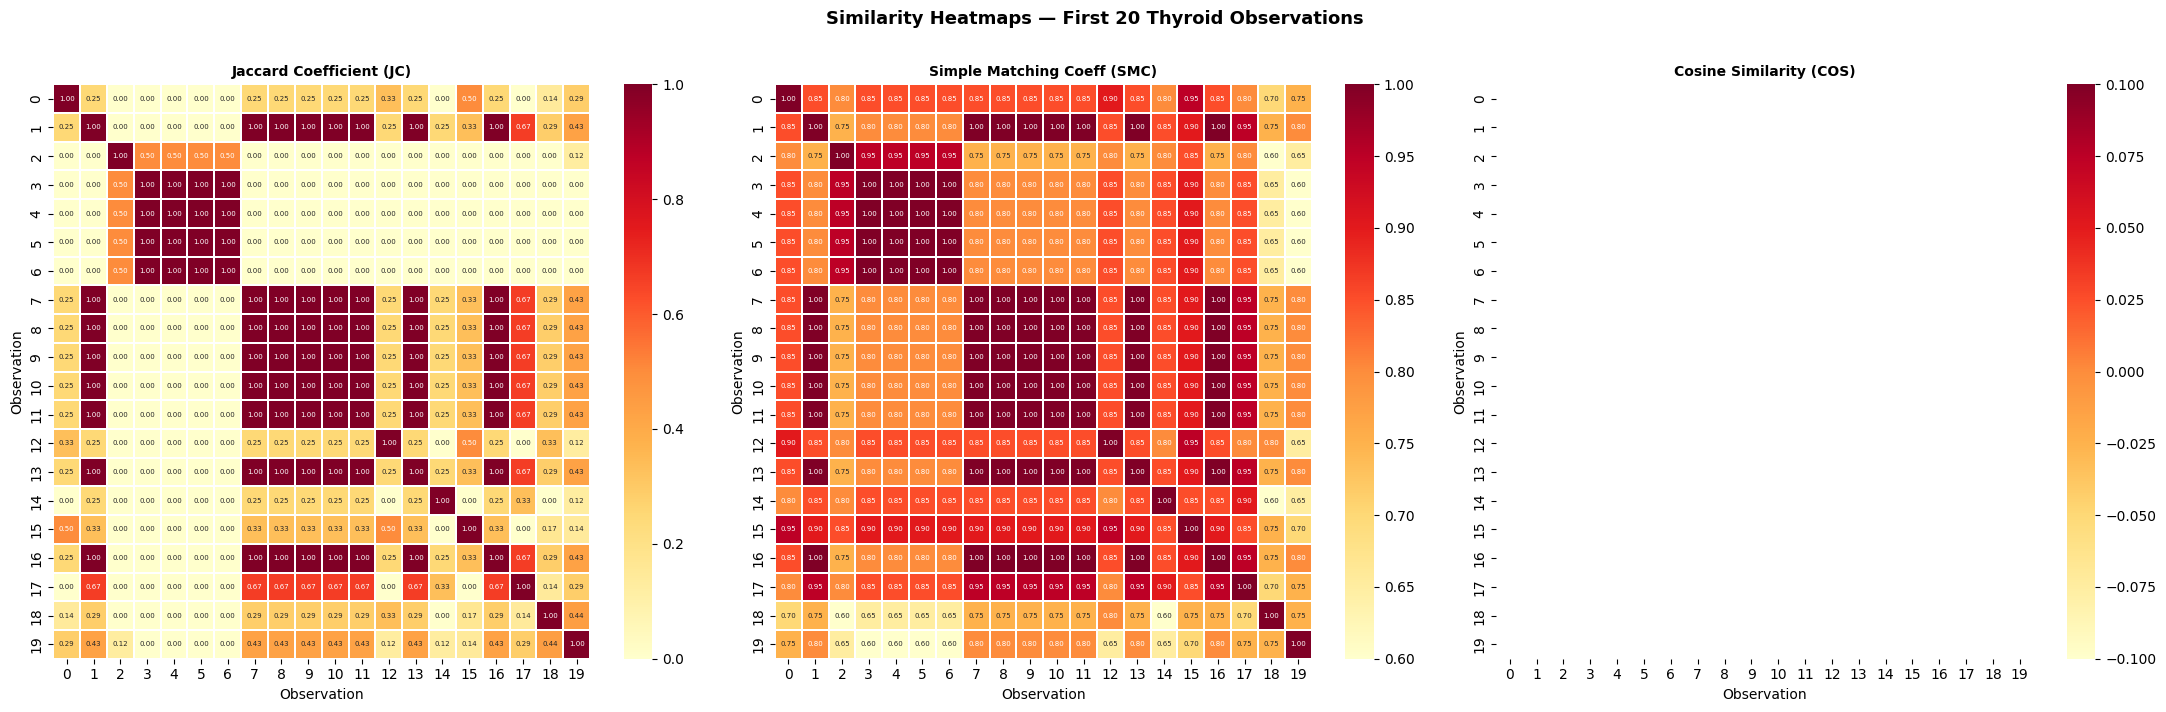

=== A7: Heatmaps rendered above ===
Diagonal = 1.0 (self-similarity). SMC >= JC due to 0-0 matches counted.
Cosine uses full encoded feature vectors and is scale-invariant.


In [12]:
def build_similarity_matrix(vectors, sim_func):
    n = len(vectors)
    mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            mat[i][j] = sim_func(vectors[i], vectors[j])
    return mat

def plot_heatmap(matrix, title, ax):
    sns.heatmap(matrix, annot=True, fmt='.2f', cmap='YlOrRd',
                linewidths=0.3, ax=ax, cbar=True, annot_kws={'size': 5})
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Observation')
    ax.set_ylabel('Observation')

def main_a7():
    df = load_thyroid_data('Lab Session Data.xlsx')
    binary_cols, _, _ = identify_dtypes(df)

    n = 20
    bin_vecs = extract_binary_vectors(df, binary_cols, list(range(n)))
    full_vecs = [prepare_full_vector(df, i) for i in range(n)]

    jc_mat = build_similarity_matrix(bin_vecs, jaccard_coefficient)
    smc_mat = build_similarity_matrix(bin_vecs, simple_matching_coefficient)
    cos_mat = build_similarity_matrix(full_vecs, cosine_similarity)

    fig, axes = plt.subplots(1, 3, figsize=(22, 7))
    plot_heatmap(jc_mat, 'Jaccard Coefficient (JC)', axes[0])
    plot_heatmap(smc_mat, 'Simple Matching Coeff (SMC)', axes[1])
    plot_heatmap(cos_mat, 'Cosine Similarity (COS)', axes[2])
    plt.suptitle('Similarity Heatmaps — First 20 Thyroid Observations',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    print("=== A7: Heatmaps rendered above ===")
    print("Diagonal = 1.0 (self-similarity). SMC >= JC due to 0-0 matches counted.")
    print("Cosine uses full encoded feature vectors and is scale-invariant.")

main_a7()

## A8 — Data Imputation

In [13]:
def has_outliers(series):
    s = pd.to_numeric(series, errors='coerce').dropna()
    if len(s) == 0:
        return False
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return bool(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).any())

def impute_dataframe(df, binary_cols, numeric_cols, categorical_cols):
    df_imp = df.copy()
    strategy_log = {}

    for col in numeric_cols:
        df_imp[col] = pd.to_numeric(df_imp[col], errors='coerce')
        if df_imp[col].isnull().any():
            if has_outliers(df_imp[col]):
                fill_val = df_imp[col].median()
                strategy_log[col] = f'median ({fill_val:.4f})'
            else:
                fill_val = df_imp[col].mean()
                strategy_log[col] = f'mean ({fill_val:.4f})'
            df_imp[col].fillna(fill_val, inplace=True)

    for col in binary_cols + categorical_cols:
        if df_imp[col].isnull().any():
            mode_val = df_imp[col].mode()
            if len(mode_val) > 0:
                df_imp[col].fillna(mode_val[0], inplace=True)
                strategy_log[col] = f'mode ({mode_val[0]})'

    return df_imp, strategy_log

def main_a8():
    df = load_thyroid_data('Lab Session Data.xlsx')
    binary_cols, numeric_cols, categorical_cols = identify_dtypes(df)
    df_imp, strategy_log = impute_dataframe(df, binary_cols, numeric_cols, categorical_cols)

    print("=== A8: Data Imputation ===")
    print("Imputation strategies applied:")
    for col, strat in strategy_log.items():
        print(f"  {col:20s}: {strat}")

    remaining = df_imp.isnull().sum().sum()
    print(f"\nTotal missing values after imputation: {remaining}")
    print(f"Shape after imputation: {df_imp.shape}")
    return df_imp

df_imputed = main_a8()

=== A8: Data Imputation ===
Imputation strategies applied:
  TSH                 : median (1.4000)
  T3                  : median (1.9000)
  TT4                 : median (104.0000)
  T4U                 : median (0.9600)
  FTI                 : median (109.0000)
  TBG                 : median (26.0000)
  sex                 : mode (F)

Total missing values after imputation: 0
Shape after imputation: (9172, 31)


## A9 — Data Normalization / Scaling

=== A9: Data Normalization ===
Normalization technique per column:
  Record ID      : Z-score (wide range)
  age            : Z-score (wide range)
  TSH            : Z-score (wide range)
  T3             : Min-Max [0,1]
  TT4            : Z-score (wide range)
  T4U            : Min-Max [0,1]
  FTI            : Z-score (wide range)
  TBG            : Z-score (wide range)

Normalized column statistics:
  Record ID      : min=-1.6020, max=2.2648, mean=0.0000
  age            : min=-0.0613, max=55.2819, mean=0.0000
  TSH            : min=-0.2108, max=22.7591, mean=-0.0000
  T3             : min=0.0000, max=1.0000, mean=0.1059
  TT4            : min=-2.9074, max=13.4219, mean=0.0000
  T4U            : min=0.0000, max=1.0000, mean=0.3725
  FTI            : min=-2.8159, max=19.3319, mean=-0.0000
  TBG            : min=-6.2424, max=41.6650, mean=0.0000


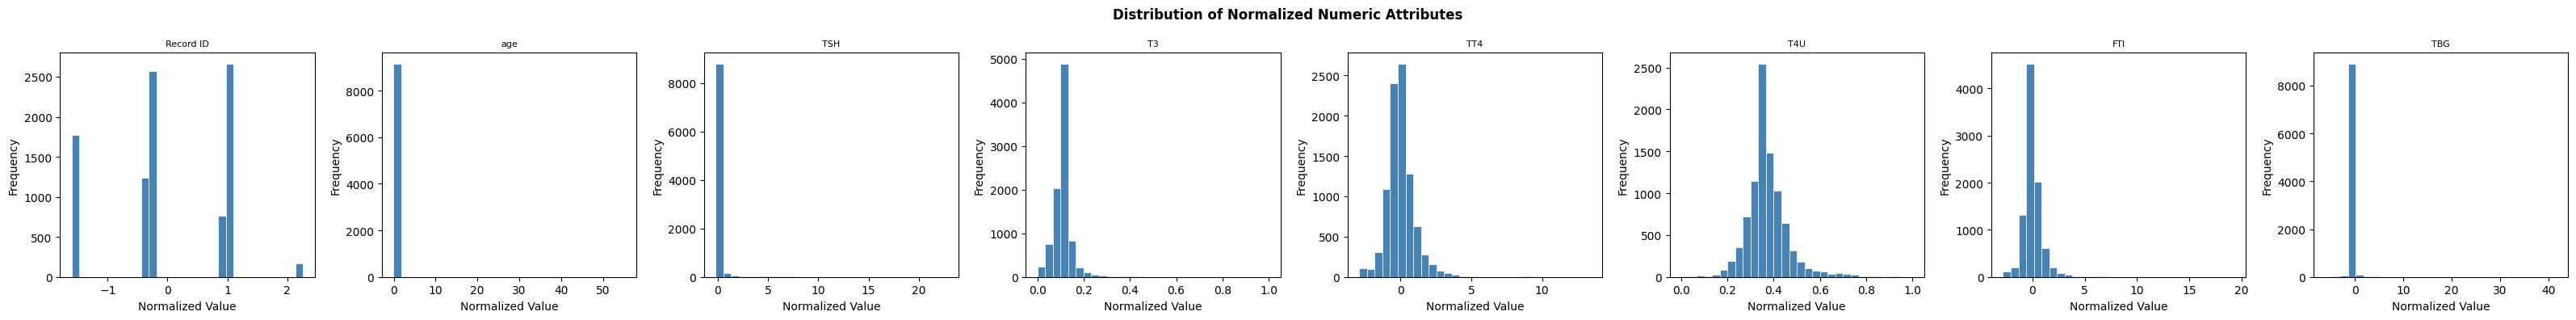

In [14]:
def min_max_normalize(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return series * 0
    return (series - mn) / (mx - mn)

def z_score_normalize(series):
    mu, sigma = series.mean(), series.std()
    if sigma == 0:
        return series * 0
    return (series - mu) / sigma

def normalize_dataframe(df_imp, numeric_cols):
    df_norm = df_imp.copy()
    norm_log = {}
    for col in numeric_cols:
        series = pd.to_numeric(df_norm[col], errors='coerce')
        clean = series.dropna()
        if len(clean) == 0:
            continue
        col_range = clean.max() - clean.min()
        if col_range > 100:
            df_norm[col] = z_score_normalize(series)
            norm_log[col] = 'Z-score (wide range)'
        else:
            df_norm[col] = min_max_normalize(series)
            norm_log[col] = 'Min-Max [0,1]'
    return df_norm, norm_log

def main_a9():
    df = load_thyroid_data('Lab Session Data.xlsx')
    binary_cols, numeric_cols, categorical_cols = identify_dtypes(df)
    df_imp, _ = impute_dataframe(df, binary_cols, numeric_cols, categorical_cols)
    df_norm, norm_log = normalize_dataframe(df_imp, numeric_cols)

    print("=== A9: Data Normalization ===")
    print("Normalization technique per column:")
    for col, tech in norm_log.items():
        print(f"  {col:15s}: {tech}")

    print("\nNormalized column statistics:")
    for col in norm_log:
        vals = pd.to_numeric(df_norm[col], errors='coerce').dropna()
        print(f"  {col:15s}: min={vals.min():.4f}, max={vals.max():.4f}, mean={vals.mean():.4f}")

    cols_to_plot = list(norm_log.keys())
    fig, axes = plt.subplots(1, len(cols_to_plot), figsize=(4 * len(cols_to_plot), 4))
    if len(cols_to_plot) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols_to_plot):
        vals = pd.to_numeric(df_norm[col], errors='coerce').dropna()
        ax.hist(vals, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
        ax.set_title(col, fontsize=8)
        ax.set_xlabel('Normalized Value')
        ax.set_ylabel('Frequency')
    plt.suptitle('Distribution of Normalized Numeric Attributes', fontweight='bold')
    plt.tight_layout()
    plt.show()

main_a9()